# Initial Data Loading

All .parquet files of `data/dataset_part_*.parquet` will be read, and then concated into a single data frame.

In [ ]:
# import pandas as pd
# import numpy as np
# from matplotlib import pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_rows', 120)

%matplotlib inline

In [ ]:
import glob

parquet_files = glob.glob('../data/*.parquet')
data_frames = [pd.read_parquet(file, engine='fastparquet') for file in parquet_files]
data_frame = pd.concat(data_frames, ignore_index=True) if data_frames else None

if not data_frames:
    print("No se encontraron archivos .parquet en el directorio 'data'.")

In [ ]:
with open('../data/bad-words.txt') as file:
    bad_words = set(map(lambda word: word[0:-1], file.readlines()))

print(bad_words)

In [ ]:
# Find comments that contain the word "t"
mask = data_frame['comment_text'].str.contains(r'\bt\b', case=False, na=False, regex=True)
comments_with_t = data_frame[mask]
comments_with_t.head()

# 0 - 250
print(len(comments_with_t['comment_text'][13]))

In [ ]:
# (A) Overall (existing idea)
# (B) toxic == 1 - with IQR fence percentile annotation
# (C) toxic == 0
# (D) Creative outlier view for toxic == 1 (Modified Z-score + IQR fence)

# -----------------------------
# PREPARACIÓN DE DATOS
# -----------------------------
all_len = data_frame['comment_text'].str.len().dropna()
all_sorted = all_len.sort_values().reset_index(drop=True)
all_pct = (all_sorted.index + 1) / len(all_sorted) * 100

toxic1_len = data_frame.loc[data_frame['toxic'] == 1, 'comment_text'].str.len().dropna()
toxic1_sorted = toxic1_len.sort_values().reset_index(drop=True)
toxic1_pct = (toxic1_sorted.index + 1) / len(toxic1_sorted) * 100

toxic0_len = data_frame.loc[data_frame['toxic'] == 0, 'comment_text'].str.len().dropna()
toxic0_sorted = toxic0_len.sort_values().reset_index(drop=True)
toxic0_pct = (toxic0_sorted.index + 1) / len(toxic0_sorted) * 100

fig, axs = plt.subplots(2, 2, figsize=(18, 10))
ax0, ax1, ax2, ax3 = axs.ravel()

# -----------------------------
# A) Overall
# -----------------------------
ax0.plot(all_pct, all_sorted, linewidth=1.1, color='steelblue')
ax0.set_title('All comments: Character Length by Percentile')
ax0.set_xlabel('Percentile of comments (%)')
ax0.set_ylabel('Character Length')

mean_len = all_len.mean()
p95 = all_len.quantile(0.95)
p99 = all_len.quantile(0.99)

ax0.axhline(mean_len, color='red', linestyle='--', label=f'Mean: {mean_len:.1f}')
ax0.axhline(p95, color='orange', linestyle='--', label=f'95th pct: {p95:.0f}')
ax0.axhline(p99, color='purple', linestyle='--', label=f'99th pct: {p99:.0f}')
ax0.axvline(95, color='gray', linestyle=':', alpha=0.8)
ax0.axvline(99, color='gray', linestyle=':', alpha=0.8)
ax0.legend()

# -----------------------------
# B) toxic == 1
# -----------------------------
ax1.plot(toxic1_pct, toxic1_sorted, linewidth=1.1, color='crimson')
ax1.set_title('toxic = 1: Character Length by Percentile')
ax1.set_xlabel('Percentile within toxic=1 (%)')
ax1.set_ylabel('Character Length')

t1_mean = toxic1_len.mean()
t1_p95 = toxic1_len.quantile(0.95)

ax1.axhline(t1_mean, color='black', linestyle='--', alpha=0.8, label=f'Mean: {t1_mean:.1f}')
ax1.axhline(t1_p95, color='orange', linestyle='--', alpha=0.9, label=f'95th pct: {t1_p95:.0f}')

# ➤ NUEVO: mostrar el percentil donde cae ese valor
t1_p95_pct = (toxic1_sorted <= t1_p95).sum() / len(toxic1_sorted) * 100
ax1.axvline(t1_p95_pct, color='gray', linestyle=':', alpha=0.8)
ax1.text(t1_p95_pct, t1_p95, f"{t1_p95_pct:.1f}%", color='orange')

ax1.legend()

# -----------------------------
# C) toxic == 0
# -----------------------------
ax2.plot(toxic0_pct, toxic0_sorted, linewidth=1.1, color='seagreen')
ax2.set_title('toxic = 0: Character Length by Percentile')
ax2.set_xlabel('Percentile within toxic=0 (%)')
ax2.set_ylabel('Character Length')

t0_mean = toxic0_len.mean()
t0_p95 = toxic0_len.quantile(0.95)

ax2.axhline(t0_mean, color='black', linestyle='--', alpha=0.8, label=f'Mean: {t0_mean:.1f}')
ax2.axhline(t0_p95, color='orange', linestyle='--', alpha=0.9, label=f'95th pct: {t0_p95:.0f}')

# ➤ NUEVO: percentil correspondiente al valor 95th
t0_p95_pct = (toxic0_sorted <= t0_p95).sum() / len(toxic0_sorted) * 100
ax2.axvline(t0_p95_pct, color='gray', linestyle=':', alpha=0.8)
ax2.text(t0_p95_pct, t0_p95, f"{t0_p95_pct:.1f}%", color='orange')

ax2.legend()

# -----------------------------
# D) Outliers toxic == 1
# -----------------------------
median_t1 = toxic1_len.median()
mad_t1 = (toxic1_len - median_t1).abs().median()

if mad_t1 == 0:
    robust_score = (toxic1_len - toxic1_len.mean()) / (toxic1_len.std() + 1e-9)
else:
    robust_score = 0.6745 * (toxic1_len - median_t1) / mad_t1

q1_t1, q3_t1 = toxic1_len.quantile([0.25, 0.75])
iqr_t1 = q3_t1 - q1_t1
upper_fence_t1 = q3_t1 + 1.5 * iqr_t1

t1_df = pd.DataFrame({
    'char_length': toxic1_len.values,
    'robust_score': robust_score.values
}).sort_values('char_length').reset_index(drop=True)

t1_df['pct'] = (t1_df.index + 1) / len(t1_df) * 100
outlier_mask = (t1_df['robust_score'].abs() > 3.5) | (t1_df['char_length'] > upper_fence_t1)

ax3.plot(t1_df['pct'], t1_df['char_length'], color='lightgray', linewidth=1.0, label='toxic=1')
ax3.scatter(
    t1_df.loc[outlier_mask, 'pct'],
    t1_df.loc[outlier_mask, 'char_length'],
    s=14, color='darkred', alpha=0.8, label='Outliers'
)

ax3.axhline(upper_fence_t1, color='navy', linestyle='--', label=f'IQR upper fence: {upper_fence_t1:.0f}')

# ➤ NUEVO: percentil donde cae el IQR upper fence
fence_pct = (t1_df['char_length'] <= upper_fence_t1).sum() / len(t1_df) * 100
ax3.axvline(fence_pct, color='navy', linestyle=':', alpha=0.8)
ax3.text(fence_pct, upper_fence_t1, f"{fence_pct:.1f}%", color='navy')

ax3.set_title('toxic = 1: Outliers (Modified Z-score + IQR)')
ax3.set_xlabel('Percentile within toxic=1 (%)')
ax3.set_ylabel('Character Length')
ax3.legend()

plt.tight_layout()
plt.show()

# Data Preview

In [20]:
print(data_frame.shape)
data_frame.head()

(223549, 11)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate,char_length,avg_word_length,word_count
0,55f8740d1450525d,My Draft of Kaithal honour killing case,0,0,0,0,0,0,39,4.875000,7
1,55fbe6ff46b630f1,"""\n\n """"German speaking Jews are not """"Germans...",0,0,0,0,0,0,313,5.905660,52
2,55fc9ccbd4c725b7,"Are you sure! Oh my gosh, I wanna see it!!! Wh...",0,0,0,0,0,0,205,5.000000,40
3,55fdcb86753ca401,"""\nand i think it was yung eaazy himself!\n""",0,0,0,0,0,0,42,3.818182,10
4,55ff7d143c66cdfb,"""\n\nTDD-1\n\nA proposed deletion template has...",0,0,0,0,0,0,1053,5.982955,175


In [ ]:
data_frame.describe().round(3)

In [ ]:
# 2. Identificación de columnas booleanas (Etiquetas)
target_columns = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
print("Columnas de etiquetas identificadas:", target_columns)

# 3. Cálculo de balance de clases por columna (Conteos)
counts = {col: data_frame[col].value_counts() for col in target_columns}
print("Conteo de registros por etiqueta:")
for col, count in counts.items():
    print(f"\n{col}:\n{count}")

# 4. Análisis porcentual de distribución
percentages = {col: (data_frame[col].value_counts(normalize=True) * 100) for col in target_columns}
print("\nDistribución porcentual (0 = No, 1 = Sí):")
for col, perc in percentages.items():
    print(f"{col}: {perc[1]:.2f}% son positivos")

# 5. Selección del Target principal
# El profesor sugiere la más equilibrada. Por lo general, 'toxic' es la que tiene más '1s'.
target = 'toxic' 
print(f"\n[DECISIÓN]: Seleccionamos '{target}' como variable objetivo por ser la más frecuente.")

In [ ]:
# 6. Inspección de inconsistencias (Ejemplo: Amenaza sin ser tóxico)
inconsistencies = data_frame[(data_frame['threat'] == 1) & (data_frame['toxic'] == 0)]
print(f"Cantidad de comentarios que son 'amenaza' pero no 'tóxicos': {len(inconsistencies)}")
inconsistencies[['comment_text', 'threat', 'toxic']].head()

In [ ]:
# 7. Creación de métricas de longitud
data_frame['char_length'] = data_frame['comment_text'].str.len()

# 8. Comparación de promedios de longitud
avg_length = data_frame.groupby(target)['char_length'].mean()
print("Promedio de longitud de caracteres:")
print(avg_length)

# 9. Detección de valores atípicos (Outliers)
plt.figure(figsize=(10, 6))
sns.boxplot(x='toxic', y='char_length', data=data_frame)
plt.title('Distribución de longitud por toxicidad')
plt.ylim(0, 2000) # Limitamos para ver mejor la caja
plt.show()

# 10. Análisis de frecuencia de términos ofensivos
# Función simple para extraer palabras
def get_top_words(text_series, n=10, filtered=False):
    words = " ".join(text_series).lower().split()
    words = map(lambda word: word.strip(), words)
    words = filter(lambda word: word in bad_words, words) if filtered else words
    return Counter(words).most_common(n)

toxic_words = get_top_words(data_frame[data_frame[target] == 1]['comment_text'], 20)
filtered_toxic_words = get_top_words(data_frame[data_frame[target] == 1]['comment_text'], 20, True)

print("Palabras más frecuentes en comentarios tóxicos:")
print(toxic_words)

print("Malas Palabras más frecuentes en comentarios tóxicos:")
print(filtered_toxic_words)

In [ ]:
# Histograma de palabras más usadas por clase usando media de frecuencias (toxic=1 vs toxic=0)

top_n = 20

def tokenize(text):
    tokens = re.findall("[a-zA-Z']+", str(text).lower())
    return [t for t in tokens if len(t) > 2]

toxic_counter = Counter(
    token
    for text in data_frame.loc[data_frame[target] == 1, 'comment_text'].dropna()
    for token in tokenize(text)
)

non_toxic_counter = Counter(
    token
    for text in data_frame.loc[data_frame[target] == 0, 'comment_text'].dropna()
    for token in tokenize(text)
)

# Unificamos vocabulario y calculamos media por palabra
all_words = set(toxic_counter) | set(non_toxic_counter)
mean_df = pd.DataFrame({'word': list(all_words)})
mean_df['toxic_count'] = mean_df['word'].map(toxic_counter).fillna(0).astype(int)
mean_df['non_toxic_count'] = mean_df['word'].map(non_toxic_counter).fillna(0).astype(int)
mean_df['mean_count'] = mean_df[['toxic_count', 'non_toxic_count']].mean(axis=1)

# Top palabras según media
top_mean_words = mean_df.nlargest(top_n, 'mean_count').sort_values('mean_count', ascending=True)

# Formato largo para comparar ambas clases en las mismas palabras
plot_df = top_mean_words.melt(
    id_vars='word',
    value_vars=['toxic_count', 'non_toxic_count'],
    var_name='class',
    value_name='count'
)
plot_df['class'] = plot_df['class'].map({
    'toxic_count': f'{target}=1',
    'non_toxic_count': f'{target}=0'
})

plt.figure(figsize=(12, 9))
sns.barplot(data=plot_df, x='count', y='word', hue='class')
plt.title(f'Top {top_n} palabras por media de frecuencia entre clases')
plt.xlabel('Frecuencia')
plt.ylabel('Palabra')
plt.tight_layout()
plt.show()

# 4 Histogram Subplots for Comprehensive EDA

In [ ]:
# Generate word_count column needed for the histograms below
data_frame['word_count'] = data_frame['comment_text'].apply(lambda x: len(str(x).split()))

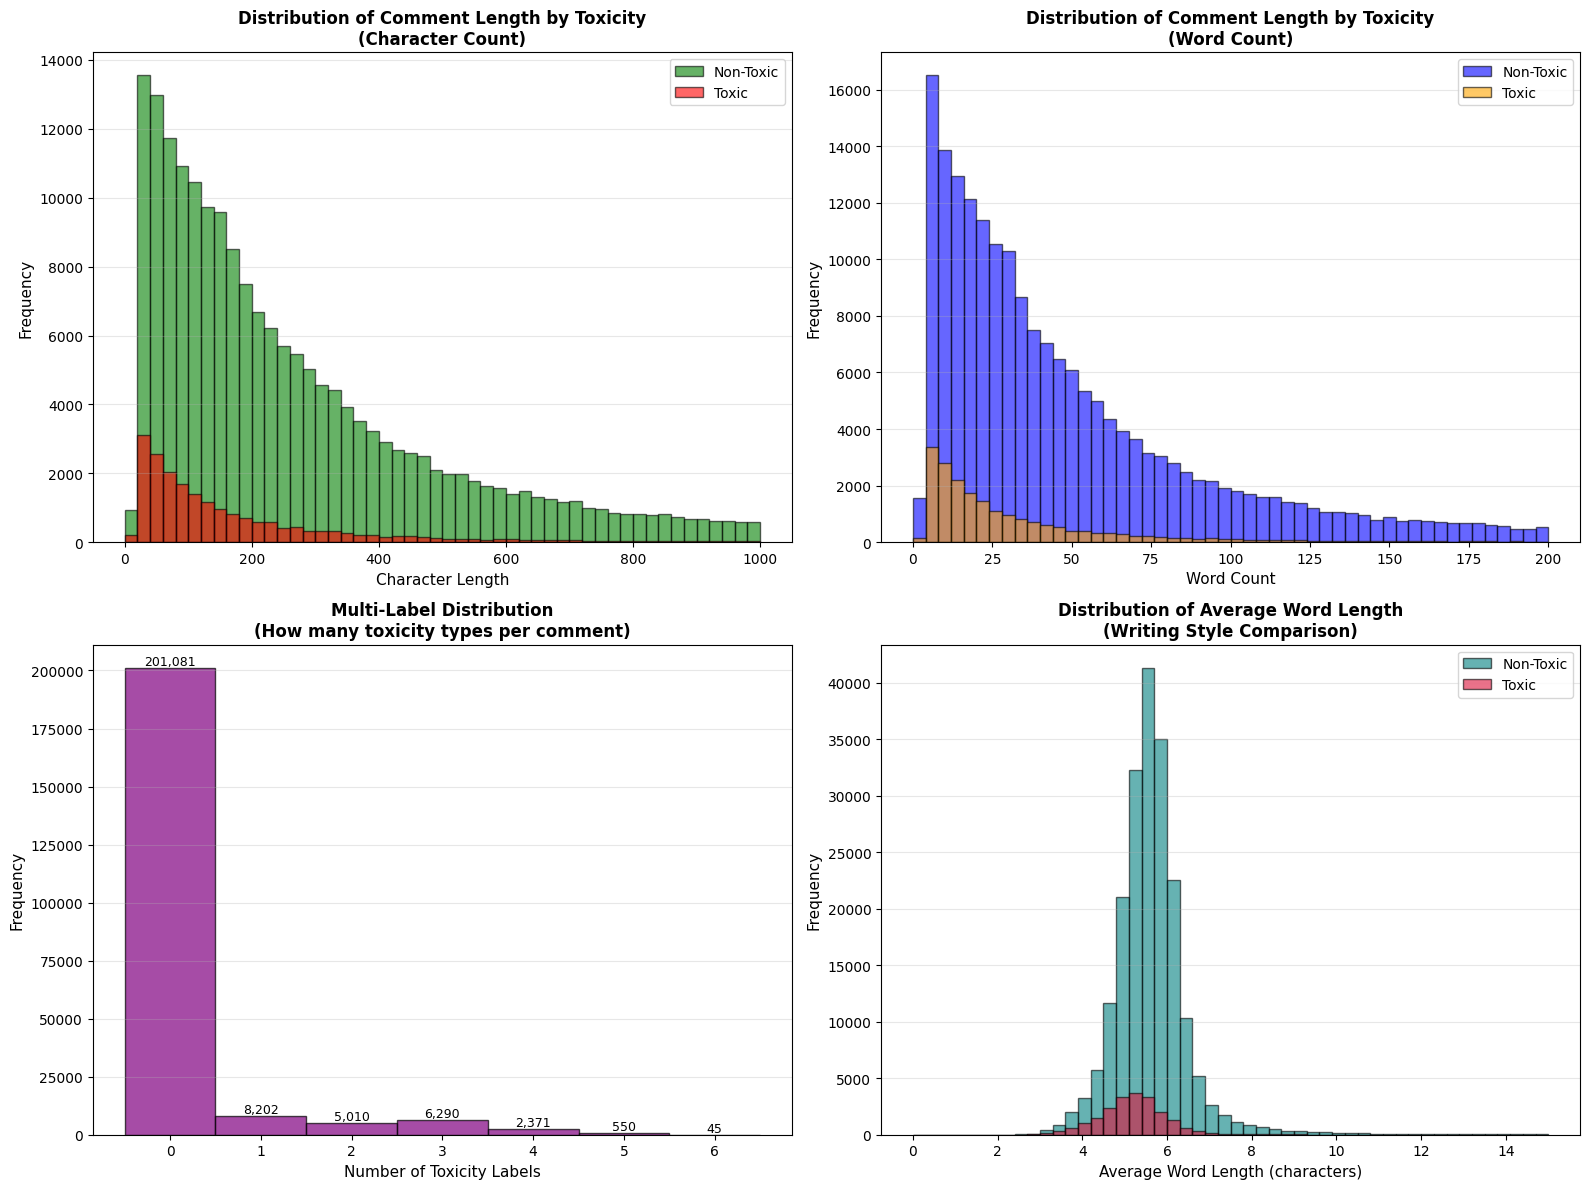

SUMMARY STATISTICS

1. Character Length:
   Toxic:     Mean = 280.6, Median = 115.0
   Non-Toxic: Mean = 402.7, Median = 215.0

2. Word Count:
   Toxic:     Mean = 48.6, Median = 21.0
   Non-Toxic: Mean = 68.4, Median = 37.0

3. Multi-Label Distribution:
   0 labels: 201,081 comments (89.95%)
   1 labels: 8,202 comments (3.67%)
   2 labels: 5,010 comments (2.24%)
   3 labels: 6,290 comments (2.81%)
   4 labels: 2,371 comments (1.06%)
   5 labels: 550 comments (0.25%)
   6 labels: 45 comments (0.02%)

4. Average Word Length:
   Toxic:     Mean = 5.70, Median = 5.21
   Non-Toxic: Mean = 5.70, Median = 5.57


In [19]:
# Create 4 meaningful histogram subplots for EDA
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Character Length Distribution (Toxic vs Non-Toxic)
ax1 = axes[0, 0]
toxic_lengths = data_frame[data_frame['toxic'] == 1]['char_length'].dropna()
non_toxic_lengths = data_frame[data_frame['toxic'] == 0]['char_length'].dropna()

ax1.hist(non_toxic_lengths, bins=50, alpha=0.6, label='Non-Toxic', color='green', edgecolor='black', range=(0, 1000))
ax1.hist(toxic_lengths, bins=50, alpha=0.6, label='Toxic', color='red', edgecolor='black', range=(0, 1000))
ax1.set_xlabel('Character Length', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.set_title('Distribution of Comment Length by Toxicity\n(Character Count)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Subplot 2: Word Count Distribution (Toxic vs Non-Toxic)
ax2 = axes[0, 1]
toxic_words = data_frame[data_frame['toxic'] == 1]['word_count'].dropna()
non_toxic_words = data_frame[data_frame['toxic'] == 0]['word_count'].dropna()

ax2.hist(non_toxic_words, bins=50, alpha=0.6, label='Non-Toxic', color='blue', edgecolor='black', range=(0, 200))
ax2.hist(toxic_words, bins=50, alpha=0.6, label='Toxic', color='orange', edgecolor='black', range=(0, 200))
ax2.set_xlabel('Word Count', fontsize=11)
ax2.set_ylabel('Frequency', fontsize=11)
ax2.set_title('Distribution of Comment Length by Toxicity\n(Word Count)', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

# Subplot 3: Number of Toxicity Labels per Comment
ax3 = axes[1, 0]
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
label_counts = data_frame[label_cols].sum(axis=1)

ax3.hist(label_counts, bins=range(0, 8), alpha=0.7, color='purple', edgecolor='black', align='left')
ax3.set_xlabel('Number of Toxicity Labels', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Multi-Label Distribution\n(How many toxicity types per comment)', fontsize=12, fontweight='bold')
ax3.set_xticks(range(0, 7))
ax3.grid(axis='y', alpha=0.3)

# Annotate bars with counts
for i in range(7):
    count = (label_counts == i).sum()
    ax3.text(i, count, f'{count:,}', ha='center', va='bottom', fontsize=9)

# Subplot 4: Average Word Length (chars/words ratio)
ax4 = axes[1, 1]
data_frame['avg_word_length'] = data_frame['char_length'] / (data_frame['word_count'] + 1)  # +1 to avoid division by zero
toxic_avg_word = data_frame[data_frame['toxic'] == 1]['avg_word_length'].dropna()
non_toxic_avg_word = data_frame[data_frame['toxic'] == 0]['avg_word_length'].dropna()

ax4.hist(non_toxic_avg_word, bins=50, alpha=0.6, label='Non-Toxic', color='teal', edgecolor='black', range=(0, 15))
ax4.hist(toxic_avg_word, bins=50, alpha=0.6, label='Toxic', color='crimson', edgecolor='black', range=(0, 15))
ax4.set_xlabel('Average Word Length (characters)', fontsize=11)
ax4.set_ylabel('Frequency', fontsize=11)
ax4.set_title('Distribution of Average Word Length\n(Writing Style Comparison)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
print(f"\n1. Character Length:")
print(f"   Toxic:     Mean = {toxic_lengths.mean():.1f}, Median = {toxic_lengths.median():.1f}")
print(f"   Non-Toxic: Mean = {non_toxic_lengths.mean():.1f}, Median = {non_toxic_lengths.median():.1f}")

print(f"\n2. Word Count:")
print(f"   Toxic:     Mean = {toxic_words.mean():.1f}, Median = {toxic_words.median():.1f}")
print(f"   Non-Toxic: Mean = {non_toxic_words.mean():.1f}, Median = {non_toxic_words.median():.1f}")

print(f"\n3. Multi-Label Distribution:")
for i in range(7):
    count = (label_counts == i).sum()
    pct = (count / len(data_frame)) * 100
    print(f"   {i} labels: {count:,} comments ({pct:.2f}%)")

print(f"\n4. Average Word Length:")
print(f"   Toxic:     Mean = {toxic_avg_word.mean():.2f}, Median = {toxic_avg_word.median():.2f}")
print(f"   Non-Toxic: Mean = {non_toxic_avg_word.mean():.2f}, Median = {non_toxic_avg_word.median():.2f}")
print("=" * 70)

## Insights from the 4 Histogram Analysis

The histograms above reveal key patterns in the toxic comment dataset:

1. **Character Length Distribution**: Compares comment lengths between toxic and non-toxic comments, revealing whether toxic comments tend to be shorter or longer
   
2. **Word Count Distribution**: Shows the distribution of the number of words, providing insight into verbosity patterns across toxicity classes

3. **Multi-Label Distribution**: Displays how many toxicity labels are assigned to each comment (0-6), revealing whether comments typically have single or multiple types of toxicity

4. **Average Word Length**: Compares writing complexity between toxic and non-toxic comments - longer words may indicate more formal language while shorter words may indicate casual or aggressive language

In [ ]:
# 11. Relación palabra-etiqueta
# Ejemplo: ¿Qué porcentaje de comentarios con la palabra 'fuck' son tóxicos?
word_to_check = 'fuck'
contains_word = data_frame[data_frame['comment_text'].str.contains(word_to_check, case=False, na=False)]
toxic_ratio = contains_word[target].mean() * 100
print(f"El {toxic_ratio:.2f}% de comentarios que contienen '{word_to_check}' están marcados como {target}.")

# 12. Exploración del contexto
print("Ejemplos de comentarios tóxicos cortos:")
print(data_frame[(data_frame[target] == 1) & (data_frame['char_length'] < 50)]['comment_text'].head())

In [ ]:
# 13. Depuración de registros ambiguos
# Si decidimos que los 35 registros de amenaza ensucian el modelo, los eliminamos:
initial_rows = len(data_frame)
data_frame = data_frame.drop(inconsistencies.index)
print(f"Registros eliminados: {initial_rows - len(data_frame)}")

# 14. Inclusión de columnas auxiliares
# Podríamos añadir conteo de palabras (no solo caracteres)
data_frame['word_count'] = data_frame['comment_text'].apply(lambda x: len(str(x).split()))

# Conclusiones del EDA
Basado en el análisis realizado:

- Desbalance: El dataset está fuertemente desbalanceado hacia la clase 0 (no tóxico).
- Longitud: Los comentarios tóxicos tienden a ser [más cortos/más largos] que los neutrales (ver punto 8).
- Vocabulario: Palabras como "fuck" tienen una correlación extremadamente alta con la etiqueta de toxicidad.

Limpieza: Se eliminaron registros inconsistentes donde había amenazas no catalogadas como tóxicas para evitar confundir al modelo.